### **Statistical testing**
Steps involved in statistical tests(Hypothesis testing)
-------------------------------------------------------
step 1: Formulate the Null Hypothesis(H0) and ALternative Hypothesis(H1)

step-2: Level of significance(aplha)

step-3: Check for Normality of given data (for Continuous data only) -> 1 sample
        Check for variances are equal(2 or more samples)

step-4: Select the statistical Test and calculate p value

step-5: Based on p-value , consider the hypothesis test

        if p <= alpha (p low Null go) -> Reject H0
        
        if p > alpha (p high Null fly) -> do  not reject H0
### Option 1: Skewness

If skewness is between −1 and +1 → data is approximately normal

If skewness < −1 → left-skewed distribution

If skewness > +1 → right-skewed distribution

👉 In simple terms:

Skewness tells you if data is tilted left or right

### Option 2: Density Curve

If the curve is symmetrical → normal distribution

If not symmetrical → skewed distribution

👉 Think:

Bell-shaped = normal

Tilted shape = skewed

### Option 3: Shapiro-Wilk Test

H₀ (null hypothesis): Data is normal

H₁ (alternative): Data is not normal

Decision:

If p-value > α (like 0.05) → data is normal

If p-value < α → data is not normal

💡 Easy Trick to Remember:

Shape → symmetric? → normal

Skewness → between -1 and 1? → normal

Test → p > 0.05? → normal

### **1-Sample Z test**
### Fabric Data
The length of 25 samples of a fabric are taken at random. Mean and standard deviation from the historic 2 years study are 150 and 4 respectively.
Test if the current mean is greater than the historic mean. Assume α = 0.05.
### Solution:
Given 1 sample, data is normal & population standard deviation is known 
### → 1-Sample Z test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel(r'C:\Users\nagasri15\Downloads\Fabric data.xlsx')
df

,Fabric_length
0,151.2
1,160.3
2,147.5
3,149.2
4,159.2
5,155.6
6,148.1
7,154.8
8,156.8
9,167.5


In [7]:
df.head()

,Fabric_length
0,151.2
1,160.3
2,147.5
3,149.2
4,159.2


### Step - 1: Formulation of H0 and Ha
--> H0 : Mean >= 150

--> Ha : Mean < 150
### Step - 2:Select level of significance
--> alpha = 0.05
### Step - 3: Check for normality

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
#option 1: -- skewness
df['Fabric_length'].skew()

np.float64(0.29650632012590666)

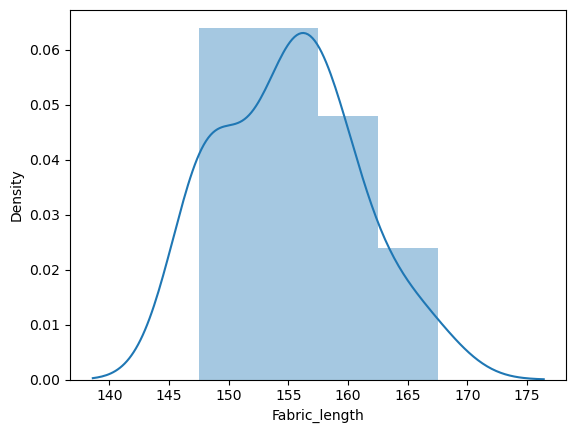

In [15]:
#option 2: Density Curve
sns.distplot(df['Fabric_length'])
plt.show()

In [5]:
from scipy import stats

In [18]:
#option 3: Shapiro Test
stats.shapiro(df['Fabric_length'])

ShapiroResult(statistic=np.float64(0.9397524078584506), pvalue=np.float64(0.1460935830606142))

### step -4: Select the statistical test and calculate p value
--> 1 sample Z test

In [19]:
df['Fabric_length'].mean()

np.float64(155.064)

In [20]:
Z_cal = (155.06 - 150) / (4/ np.sqrt(25))
Z_cal

np.float64(6.325000000000003)

In [21]:
stats.norm.cdf(Z_cal)

np.float64(0.9999999998733837)

### Step - 5: Based on p value, Accept or Reject H0
--> P > alpha

--> P High -- Null fly

--> Do not reject H0

### **1-Sample T test**
### Bolt Diameter
The mean diameter of the bolt manufactured should be 10 mm to be able to fit into the nut.
20 samples are taken at random from the production line by a quality inspector. Conduct a test to check with 95% confidence that the mean is not different from the specification.
### Solution:
Given 1 sample, data is normal & population standard deviation is unknown 
### →1-Sample T test

In [3]:
bolt = pd.read_excel(r'C:\Users\nagasri15\Downloads\Bolt diameter.xlsx')
bolt

,Diameter
0,10.00
1,10.01
2,10.02
3,9.99
4,10.00
5,10.00
6,10.00
7,10.00
8,10.00
9,10.05


### Step - 1: Formulation of H0 and Ha
--> H0 : Mean == 10

--> Ha : Mean != 10

### Step - 2:Select level of significance
--> alpha = 0.05

### Step - 3: Check for normality¶

In [6]:
bolt['Diameter'].skew()

np.float64(0.9377400845737698)

### step -4: Select the statistical test and calculate p value
--> 1 sample T test

In [11]:
stats.ttest_1samp(bolt.Diameter, 10)

TtestResult(statistic=np.float64(1.0398561501518244), pvalue=np.float64(0.3114592594451563), df=np.int64(19))

### Step - 5: Based on p value, Accept or Reject H0
--> P > alpha

--> P High -- Null fly

--> Do not reject H0(Average bolt diameter is equal to 10) -> No need to take action

### **2-Sample T test**
### Marketing Strategy
A financial analyst at a Financial institute wants to evaluate a recent credit card promption. After this promotion 500 cardholders
were randomly selected. Half received an ad promoting a full waiver of interest rate on purchases made over the next three
months, and half received a standard Christmas advertisement. Did the ad promoting full interest rate waiver, increase purchases?
### Solution:
Given 2 samples, Both are normal and 2 samples variances are equal.
### --> 2-Sample T test

In [14]:
promotion = pd.read_excel(r'C:\Users\nagasri15\Downloads\Promotion.xlsx')
promotion

,InterestRateWaiver,StandardPromotion
0,1989.10,1272.25
1,1808.38,1250.38
2,1153.75,1474.78
3,1745.64,2064.89
4,1008.24,2030.87
...,...,...
245,1730.41,2047.49
246,947.66,1685.44
247,1516.43,1840.55
248,1609.69,1603.48


### Step - 1: Formulation of H0,Ha
H0:Avg of purchases made by FIW <= Avg purchases made by SC => default/current/no action

Ha:Avg of purchases made by FIW > Avg purchases made by SC => take action
### Step - 2: Select level of significance
alpha = 0.05
### Step -3: Check for normality


In [15]:
promotion['InterestRateWaiver'].skew()

np.float64(-0.186848927819777)

In [16]:
promotion['StandardPromotion'].skew()

np.float64(0.1556560407787534)

### Variance test - Levene test
H0: Variances are equal

Ha: Variances are not equal

In [17]:
stats.levene(promotion.InterestRateWaiver, promotion.StandardPromotion)

LeveneResult(statistic=np.float64(1.1334674473666406), pvalue=np.float64(0.2875528565130808))

### Step - 4: select Statistical test & calculate the p value
2-sample t test for equal variance

In [18]:
stats.ttest_ind(promotion.InterestRateWaiver, promotion.StandardPromotion,equal_var = True)

TtestResult(statistic=np.float64(2.2604251631369405), pvalue=np.float64(0.02422584468584315), df=np.float64(498.0))

### Step - 5: Baesd on p value, accept or reject H0
--> P < alpha

--> P Low -- Null go

--> Reject H0(FIW<=SC) -- take action

In [20]:
## 2 sample t test for unequal variance
# stats.ttest_ind(promotion.InterestRateWaiver,promtotion.StandardPromotion,equal_var = False)

### **One way ANOVA test**
### Contract Renewal

A marketing organization outsources their back-office operations to three different suppliers. The contracts are up for renewal and the CMO wants to determine whether they should renew contracts with all suppliers or any specific supplier. CMO want to renew the contract of supplier with the least transaction time. CMO will renew all contracts if the performance of all suppliers is similar.

### Solution:
Given 3 Samples, All are Normal, 3 Variances are equal→

### One way ANOVA Test

In [23]:
contract = pd.read_excel(r'C:\Users\nagasri15\Downloads\Contract Renewal.xlsx')
contract

,SupplierA,SupplierB,SupplierC
0,6.15,7.87,7.41
1,6.22,5.21,3.61
2,6.76,7.94,7.23
3,4.29,7.36,5.53
4,7.08,6.17,3.97
...,...,...,...
115,5.85,4.53,4.27
116,5.04,8.06,6.39
117,5.68,7.14,4.60
118,4.77,4.84,6.15


### Step - 1: Formulation of H0,Ha
H0: μ1 = μ2 = μ3 (OR) Average time by suppliers are equal

Ha: μ1 != μ2 != μ3 (OR) Avreage time by all suppliers are not equal
### Step - 2: Select level of significance
alpha = 0.05

### Step -3: Check for normality

In [24]:
print(contract['SupplierA'].skew())
print(contract['SupplierB'].skew())
print(contract['SupplierC'].skew())

0.12032960598073747
-0.06982967935882636
0.25116833883092665


### Variance test - Levene test
H0: Variances are equal

Ha: Variances are not equal

In [25]:
stats.levene(contract.SupplierA, contract.SupplierB)

LeveneResult(statistic=np.float64(0.03382395609148779), pvalue=np.float64(0.8542383784793752))

In [26]:
stats.levene(contract.SupplierB, contract.SupplierC)

LeveneResult(statistic=np.float64(0.24333902699144816), pvalue=np.float64(0.6222596854892893))

In [27]:
stats.levene(contract.SupplierC, contract.SupplierA)

LeveneResult(statistic=np.float64(0.4712013339466693), pvalue=np.float64(0.49310323292578306))

In [28]:
stats.levene(contract.SupplierA, contract.SupplierB, contract.SupplierC)

LeveneResult(statistic=np.float64(0.25183988720942463), pvalue=np.float64(0.7775071819400866))

### Step - 4: select Statistical test & calculate the p value
one way ANOVA(F test)

In [29]:
stats.f_oneway(contract.SupplierA,contract.SupplierB,contract.SupplierC)

F_onewayResult(statistic=np.float64(2.280378701368123), pvalue=np.float64(0.10373295731933224))

### Step - 5: Baesd on p value, accept or reject H0
--> P > alpha

--> P High -- Null fly

--> Do not reject H0 All the 3 suppliers have mean transaction time

### ***1 sample proportion test***
### Football Coach
The people carried out a poll to find the acceptability of a new football coach. It was decided that if the support rate for the coach for the entire population was really less than 25%, the coach should be fired.
In a sample, 2000 people participated and 482 people supported the new coach.
Conduct a test to check if the new coach should be fired at a 95% level of confidence.
### Solution:
Given 1 sample proportion
### 1 sample proportion

### Step - 1: Formulation of H0,Ha
H0: Coach not to be fired(No action)- No difference

Ha:Coach to be fired(action)
### Step - 2: Select level of significance
aplha = 0.05
### Step - 4: Select statistical test & calculate the p value
 proportion test

In [32]:
stats.binomtest(482,2000,0.25)

BinomTestResult(k=482, n=2000, alternative='two-sided', statistic=0.241, pvalue=0.36615115821828914)

### step - 5: Based on p value ,Accept or reject H0
p > alpha

p high -- null fly

Do not reject H0

### ***2 Proportion Test***
### Johnnie Talkers 
Johnnie Talkers soft drinks division sales manager has been planning to launch a new sales
incentive program for their sales executives. The sales executives feel that adults (≥ 20 yrs)
won’t buy, while children will, and hence requested the sales manager not to launch the program.
Analyze the data and determine whether there is evidence at a 5% significance level to support the hypothesis.
### Solution:
Given 2 sample proportions 
### 2 Proprtion test

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(r'C:\Users\nagasri15\Downloads\JohnyTalkers.xlsx')
df

,Person,Drinks
0,Adults,Did Not Purchase
1,Adults,Did Not Purchase
2,Adults,Did Not Purchase
3,Adults,Did Not Purchase
4,Adults,Did Not Purchase
...,...,...
1215,Children,Did Not Purchase
1216,Children,Did Not Purchase
1217,Children,Did Not Purchase
1218,Children,Did Not Purchase


In [5]:
df['Person'].value_counts()

Person
Children    740
Adults      480
Name: count, dtype: int64

In [6]:
df['Drinks'].value_counts()

Drinks
Did Not Purchase    1010
Purchased            210
Name: count, dtype: int64

In [7]:
#crosstab
pd.crosstab(df['Person'],df['Drinks'],margins = True)

Drinks,Did Not Purchase,Purchased,All
Person,,,
Adults,422,58,480
Children,588,152,740
All,1010,210,1220


### Step - 1: Formulation of H0,Ha
H0 : Proportions of Adults >= Proportions of Children

Ha : Proportions of Adults < Proportions of Children
### Step - 2: Select level of significance
alpha = 0.05

### Step -4: Select the Statistical test & calculate p value
### 2 Proportion test

In [9]:
from statsmodels.stats.proportion import proportions_ztest

count = np.array([58, 152])#How many counts and children are purchasing
nobs = np.array([480, 740])#Total number of adults and children are there

proportions_ztest(count , nobs, alternative = 'two-sided')  

(np.float64(-3.8227247718795447), np.float64(0.00013198507287726183))

### Step - 5: Based on p value, Accept or Reject H0
P < alpha

P Low -- Null go

Reject H0

### ***Chi-Square test***
### Bahaman Research
Baha ManTech Research Company uses 4 regional centers in South Asia (India, China, Srilanka and Bangladesh) to input data of questionnaire responses. They assume certain % of the questionnaire responses were data entry. Any error in data entry renders it defective. The chief data scientist wants to check whether the defective % varies by country. Analyze the data at 5% significance level and help the manager draw appropriate inferences. ['1' means not defective & '0' means defective]
### Solution: 
Given > 2 proportions 
### → Chi-Square Test

In [10]:
df = pd.read_excel(r'C:\Users\nagasri15\Downloads\Bahaman.xlsx')
df

,Defective,Country
0,0,India
1,0,India
2,0,India
3,0,India
4,1,India
...,...,...
795,0,Bangladesh
796,0,Bangladesh
797,1,Bangladesh
798,0,Bangladesh


In [13]:
count = pd.crosstab(df['Defective'],df['Country'])
count

Country,Bangladesh,China,India,Srilanka
Defective,,,,
0,183,179,175,178
1,17,21,25,22


### Step - 1: Formulation of H0,Ha
H0 : No difference in proportion between countries

Ha : Difference in proportion between countries

### Step - 2: Select level of significance
alpha = 0.05

### Step -4: Select the Statistical test & calculate p value
Chi - Square test


In [17]:
stats.chi2_contingency(count)

Chi2ContingencyResult(statistic=np.float64(1.7243932538050184), pvalue=np.float64(0.6315243037546223), dof=3, expected_freq=array([[178.75, 178.75, 178.75, 178.75],
       [ 21.25,  21.25,  21.25,  21.25]]))

In [19]:
ChiSquares_results = stats.chi2_contingency(count)
print('p-value:',ChiSquares_results[1])

p-value: 0.6315243037546223


### Step - 5: Based on p value, Accept or Reject H0
P > alpha

P High -- Null fly

Do not reject H0

### ***Examples***
### Factory claim
### Two tailed 1 sample z test
A factory claims that the average weight of its product is 500 grams.
A sample of 50 items is taken, and the sample mean is found to be 498 grams.
The population standard deviation is known to be 20 grams.
Test whether the factory's claim is true at 5% significance level.

In [3]:
Z_cal = (490-500)/(20/np.sqrt(50))
Z_cal

np.float64(-3.5355339059327378)

In [6]:
# two tail --> (norm.sf(z_cal)*2
pvalue = 2*stats.norm.sf(Z_cal)
pvalue

np.float64(1.999593047982555)

### Inferences
p> alpha

p High--Null fly

Do not Reject H0

### Product weight
### Right tailed 1 sample t test
The average weight of a product is 260 grams, with o 10 grams.
A sample of 25 items shows a mean weight of 195 grams.
Test whether the current mean is less than the standard weight at a = 0.05.

In [8]:
Z_cal = (195-200)/(10/np.sqrt(25))
Z_cal

np.float64(-2.5)

In [9]:
pval=1-stats.norm.cdf(-2.5)
pval

np.float64(0.9937903346742238)

### Inferences
p > alpha

pHigh--Null fly

Do not Reject H0

### ***ANOVA test***
### Teaching methods
A teacher wants to test whether three different teaching methods have different effects on student performance. The scores of students taught by each method are given, Test whether there is a significant difference between the means of the three groups at a = 0.05 |

In [10]:
df = pd.read_excel(r'C:\Users\nagasri15\Downloads\anova_dataset.xlsx')
df

,Method_A,Method_B,Method_C
0,78,65,88
1,80,67,90
2,82,70,92
3,85,72,94
4,87,74,96
5,90,73,95
6,88,71,93
7,84,69,91
8,83,68,89
9,86,66,87


### Step - 1: Formulation of H0,Ha
H0: Three methods are equal 

Ha: Three methods are not equal

### Step - 2: Select level of significance
alpha = 0.05

### Step -3: Check for normality

In [11]:
print(df['Method_A'].skew())
print(df['Method_B'].skew())
print(df['Method_C'].skew())

-0.08594574986481414
-0.11819018369518287
0.006698022881984159


### Variance test - Levene test
H0: Variances are equal

Ha: Variances are not equal



In [12]:
stats.levene(df.Method_A, df.Method_B)

LeveneResult(statistic=np.float64(0.7789184672317058), pvalue=np.float64(0.38111543404902315))

In [13]:
stats.levene(df.Method_B, df.Method_C)

LeveneResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))

In [14]:
stats.levene(df.Method_C, df.Method_A)

LeveneResult(statistic=np.float64(0.8093525179856116), pvalue=np.float64(0.3720318321335686))

In [15]:
stats.levene(df.Method_A, df.Method_B,df.Method_C)

LeveneResult(statistic=np.float64(0.5744849445324881), pvalue=np.float64(0.5651158445889992))

### Step - 4: select Statistical test & calculate the p value
one way ANOVA(F test)

In [16]:
stats.f_oneway(df.Method_A, df.Method_B,df.Method_C)

F_onewayResult(statistic=np.float64(254.56351266221517), pvalue=np.float64(4.383784660832695e-37))

### Step - 5: Baesd on p value, accept or reject H0
--> P > alpha

--> P High -- Null fly

--> Do not reject H0 